Task 1: Algorithmic pathfinding and problem solving

1. Install and Libraries

- Packet install

In [1]:
!pip install osmnx networkx matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 2.1 MB/s eta 0:00:00


- Import Library

In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import math, time, heapq
from IPython.display import Image
import statistics as stats
import pandas as pd
import numpy as np
import platform, psutil, networkx as nx, matplotlib, sys
from shapely.geometry import LineString, Point
from osmnx import graph as ox_graph
from osmnx import distance as ox_distance
import tracemalloc

2. Download the graph

- Download the map and define the map

In [3]:
# Download the real graph of Oxford
place = "Oxford, UK"
G = ox.graph_from_place(place, network_type='drive')
#G = ox.simplify_graph(G)
print(f"Nodos: {len(G.nodes)}  |  Aristas: {len(G.edges)}")

# Define the Origin and Destination
origin_name = "Oxford Brookes University Headington Campus, Oxford, UK"
dest_name   = "Oxford Stadium, Oxford, UK"

# Convert names to coordinates
orig_lat, orig_lon = ox.geocode(origin_name)
dest_lat, dest_lon = ox.geocode(dest_name)

# Associate nodes of the graph more near to those coordinates
orig_node = ox.distance.nearest_nodes(G, X=orig_lon, Y=orig_lat)
dest_node = ox.distance.nearest_nodes(G, X=dest_lon, Y=dest_lat)

Nodos: 3388  |  Aristas: 7539


- Define the auxiliary function

In [4]:
# Euclidean heuristics
def heuristic(u, v):
    y1, x1 = G.nodes[u]['y'], G.nodes[u]['x']
    y2, x2 = G.nodes[v]['y'], G.nodes[v]['x']
    return math.hypot(y1 - y2, x1 - x2)

# Length of each edge
def edge_len(u, v):
    data = G.get_edge_data(u, v)[0]
    return data.get('length', heuristic(u, v))

# Total Length of the path
def path_length(G, path):
    return sum(edge_len(a, b) for a, b in zip(path[:-1], path[1:]))

3. Implement the Algorithms

- Dijkstra

In [5]:
def dijkstra(G, start, goal):
    pq = [(0, start)]
    dist, prev, visited = {start: 0}, {}, set()
    while pq:
        d, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        if u == goal:
            break
        for v in G.neighbors(u):
            w = edge_len(u, v)
            nd = d + w
            if v not in dist or nd < dist[v]:
                dist[v] = nd
                prev[v] = u
                heapq.heappush(pq, (nd, v))
    # reconstruir ruta
    path, cur = [], goal
    while cur in prev or cur == start:
        path.append(cur)
        if cur == start: break
        cur = prev[cur]
    return list(reversed(path)), len(visited)

- A*

In [6]:
def astar(G, start, goal):
    pq = [(0, start)]
    g, prev, visited = {start: 0}, {}, set()
    while pq:
        f, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        if u == goal:
            break
        for v in G.neighbors(u):
            w = edge_len(u, v)
            ng = g[u] + w
            if v not in g or ng < g[v]:
                g[v] = ng
                prev[v] = u
                heapq.heappush(pq, (ng + heuristic(v, goal), v))
    path, cur = [], goal
    while cur in prev or cur == start:
        path.append(cur)
        if cur == start: break
        cur = prev[cur]
    return list(reversed(path)), len(visited)

- GBFS (Greedy Best-First Search)

In [7]:
def greedy(G, start, goal):
    pq = [(heuristic(start, goal), start)]
    prev, visited = {}, set()
    while pq:
        h, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        if u == goal:
            break
        for v in G.neighbors(u):
            if v not in visited:
                prev[v] = u
                heapq.heappush(pq, (heuristic(v, goal), v))
    path, cur = [], goal
    while cur in prev or cur == start:
        path.append(cur)
        if cur == start: break
        cur = prev[cur]
    return list(reversed(path)), len(visited)

Task 2: Graph Representation

- 1. Run all Algorithms


In [8]:
algos = {'Dijkstra': dijkstra, 'A*': astar, 'Greedy BFS': greedy}
results, paths = [], {}

for name, func in algos.items():
    t0 = time.time()
    path, expanded = func(G, orig_node, dest_node)
    t1 = time.time()
    L = path_length(G, path)
    results.append((name, expanded, L, t1 - t0))
    paths[name] = path

print("\n=== Outcomes ===")
print(f"{'Algorithm':<12} | {'Nodes':>7} | {'Length (m)':>13} | {'Time (s)':>10}")
print("-"*50)
for n, e, l, t in results:
    print(f"{n:<12} | {e:>7} | {l:>13.2f} | {t:>10.4f}")


=== Outcomes ===
Algorithm    |   Nodes |    Length (m) |   Time (s)
--------------------------------------------------
Dijkstra     |    2560 |       5679.22 |     0.0252
A*           |    2560 |       5679.22 |     0.0211
Greedy BFS   |     113 |       7249.38 |     0.0004


- 2. Draw the map

In [9]:
fig, ax = ox.plot_graph_routes(
    G,
    list(paths.values()),
    route_colors=['r', 'g', 'b'],
    route_linewidth=3,
    node_size=5,
    show=False, close=False
)
fig.savefig("task1_routes.png", dpi=200, bbox_inches="tight")
plt.close(fig)
print("Mapa saved as task1_routes.png")

Mapa saved as task1_routes.png


- 3. Show the map

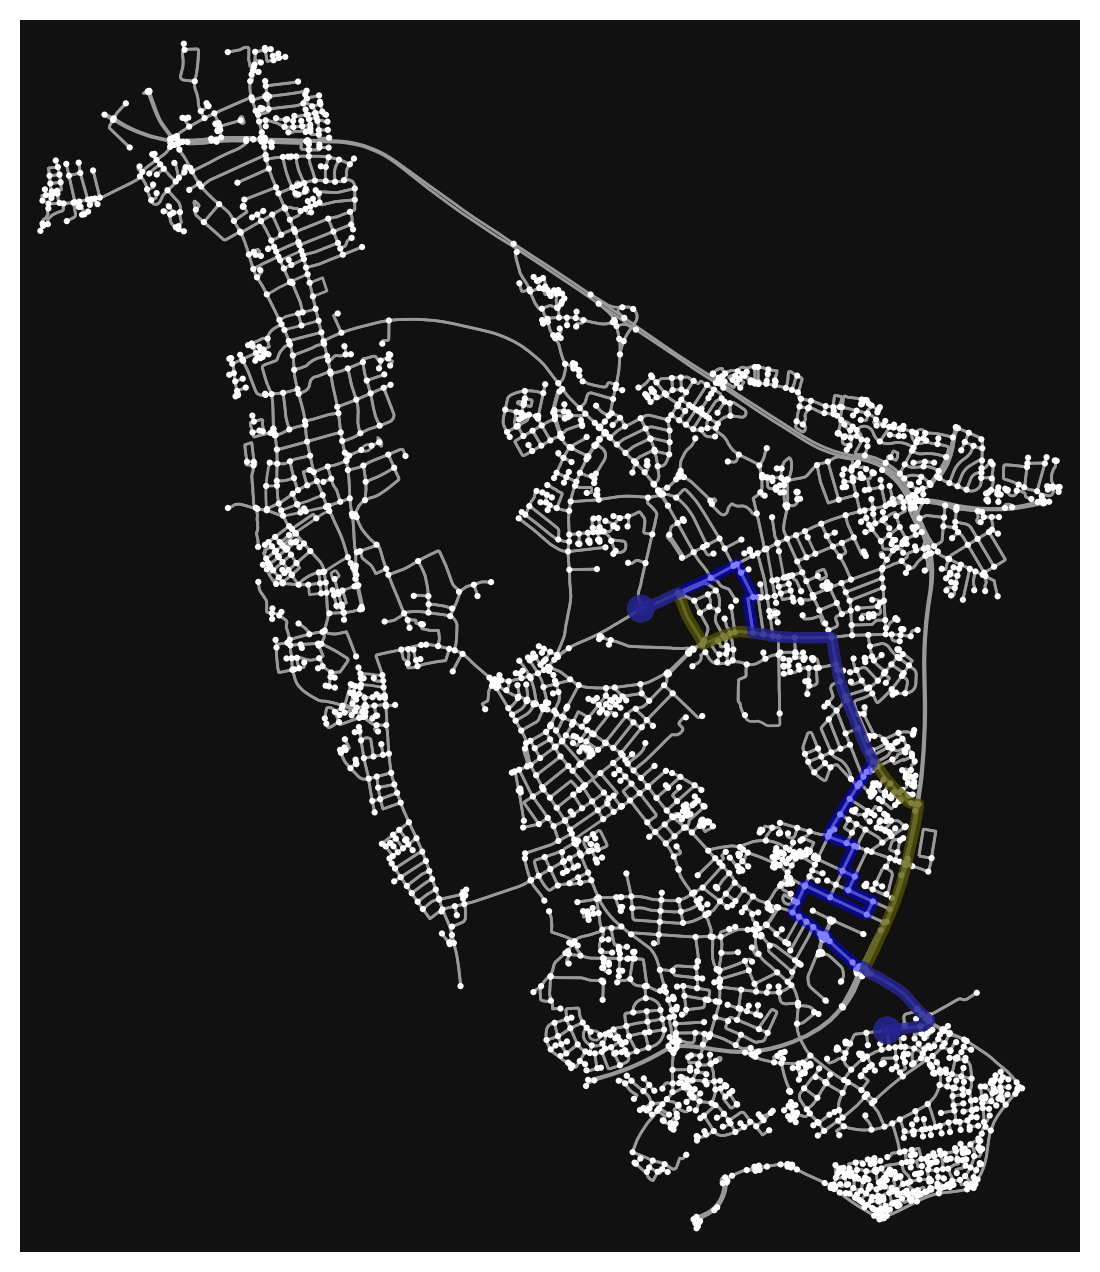

In [10]:
Image("task1_routes.png")

- 4. Check the route

In [11]:
def same_route(p1, p2):
    return p1 == p2

print("¿A* and Dijkstra are the same route?:", same_route(paths['A*'], paths['Dijkstra']))
print("¿Greedy BFS is the same that A*?:", same_route(paths['Greedy BFS'], paths['A*']))
print("Dijkstra length:", round(results[0][2], 2))
print("A* length:", round(results[1][2], 2))
print("Greedy BFS length:", round(results[2][2], 2))

¿A* and Dijkstra are the same route?: True
¿Greedy BFS is the same that A*?: False
Dijkstra length: 5679.22
A* length: 5679.22
Greedy BFS length: 7249.38


Task 3: Performance Comparison

1. Comparison of the 3 Key Algortihm

In [12]:
algos = {'Dijkstra': dijkstra, 'A*': astar, 'Greedy BFS': greedy}
results, paths = [], {}

for name, func in algos.items():
    t0 = time.time()
    path, expanded = func(G, orig_node, dest_node)
    t1 = time.time()
    L = path_length(G, path)
    results.append((name, expanded, L, t1 - t0))
    paths[name] = path

print("\n=== Outcomes ===")
print(f"{'Algorithm':<12} | {'Nodes':>7} | {'Length (m)':>13} | {'Time (s)':>10}")
print("-"*50)
for n, e, l, t in results:
    print(f"{n:<12} | {e:>7} | {l:>13.2f} | {t:>10.4f}")


=== Outcomes ===
Algorithm    |   Nodes |    Length (m) |   Time (s)
--------------------------------------------------
Dijkstra     |    2560 |       5679.22 |     0.0190
A*           |    2560 |       5679.22 |     0.0226
Greedy BFS   |     113 |       7249.38 |     0.0004


2. Optimatization

- Add time of travel

In [13]:
# Optimisation: add travel time to each edge
def prepare_travel_time(G):
    for u, v, data in G.edges(data=True):
        length = data.get("length", 1.0)
        highway = data.get("highway", "")
        if isinstance(highway, list):
            highway = highway[0]
        if highway in ("motorway", "trunk"):
            speed_kmh = 80
        elif highway in ("primary", "secondary"):
            speed_kmh = 50
        else:
            speed_kmh = 30
        speed_mps = speed_kmh * 1000 / 3600
        data["travel_time"] = length / speed_mps  # seconds

prepare_travel_time(G)

- Define A* optimized for time

In [14]:
# Optimisation: time-based A*
def astar_time(G, start, goal):
    max_speed_mps = 80 * 1000 / 3600

    def h_time(u, v):
        y1, x1 = G.nodes[u]['y'], G.nodes[u]['x']
        y2, x2 = G.nodes[v]['y'], G.nodes[v]['x']
        dist = math.hypot(y1 - y2, x1 - x2) * 111_000
        return dist / max_speed_mps

    pq = [(0, start)]
    g, prev, visited = {start: 0}, {}, set()

    while pq:
        f, u = heapq.heappop(pq)
        if u in visited: continue
        visited.add(u)
        if u == goal: break
        for v in G.neighbors(u):
            w = G[u][v].get("travel_time", 1.0)
            ng = g[u] + w
            if v not in g or ng < g[v]:
                g[v] = ng; prev[v] = u
                heapq.heappush(pq, (ng + h_time(v, goal), v))

    path, cur = [], goal
    while cur in prev or cur == start:
        path.append(cur)
        if cur == start: break
        cur = prev[cur]
    return list(reversed(path)), len(visited)

- Hierarchial A*

In [15]:
# Run baseline and optimised algorithms
algos = {
    "Dijkstra": lambda: dijkstra(G, orig_node, dest_node),
    "A*": lambda: astar(G, orig_node, dest_node),
    "Greedy BFS": lambda: greedy(G, orig_node, dest_node),
    "A* (travel time)": lambda: astar_time(G, orig_node, dest_node),
}
results = []
for name, func in algos.items():
    t0 = time.time()
    path, expanded = func()
    t1 = time.time()
    L = path_length(G if "Hierarchical" not in name else G_sub, path)
    results.append((name, expanded, L, t1 - t0))

print(f"{'Algorithm':<20} | {'Nodes':>7} | {'Length (m)':>11} | {'Time (s)':>10}")
print("-"*60)
for n, e, L, t in results:
    print(f"{n:<20} | {e:>7} | {L:>11.2f} | {t:>10.4f}")

Algorithm            |   Nodes |  Length (m) |   Time (s)
------------------------------------------------------------
Dijkstra             |    2560 |     5679.22 |     0.0204
A*                   |    2560 |     5679.22 |     0.0231
Greedy BFS           |     113 |     7249.38 |     0.0004
A* (travel time)     |     122 |     6577.49 |     0.0010


8. Fix Hierarchial A* (HPA*)

- HPA*

In [16]:
# Corridor Polygon  + "end caps" in origin/Destination
line = LineString([(orig_lon, orig_lat), (dest_lon, dest_lat)])
buf_main = 0.010   # ~1 km of wide corridor
buf_caps = 0.003   # ~300 m for cover all the extrems

corridor = (
    line.buffer(buf_main)
    .union(Point(orig_lon, orig_lat).buffer(buf_caps))
    .union(Point(dest_lon, dest_lat).buffer(buf_caps))
)

G_corr = ox_graph.graph_from_polygon(corridor, network_type="drive")

if G_corr.is_directed():
    comps = nx.weakly_connected_components(G_corr)
else:
    comps = nx.connected_components(G_corr)

largest = max(comps, key=len)
G_corr = G_corr.subgraph(largest).copy()

print(f"Corridor graph: {len(G_corr.nodes)} nodes, {len(G_corr.edges)} edges")

in_corr_o = orig_node in G_corr
in_corr_d = dest_node in G_corr
print("origin in corridor:", in_corr_o, "destination in corridor:", in_corr_d)


if in_corr_o and in_corr_d:
    orig_corr_fixed = orig_node
    dest_corr_fixed = dest_node
else:
    print("⚠️ Increase buf_main (p.ej., 0.012–0.015) till we have True/True.")

Corridor graph: 751 nodes, 1589 edges
origin in corridor: True destination in corridor: True


- HPA*: A* in the corridor subgraph

In [17]:
# === A* corridor

def _heuristic_meters(G, u, v):
    y1, x1 = G.nodes[u]['y'], G.nodes[u]['x']
    y2, x2 = G.nodes[v]['y'], G.nodes[v]['x']
    return math.hypot(y1 - y2, x1 - x2) * 111_000.0  # 1º - 111 km

def min_edge_len(G, u, v):
    data = G.get_edge_data(u, v)

    if isinstance(data, dict) and any(isinstance(val, dict) for val in data.values()):
        return min(d.get("length", 0.0) for d in data.values())

    return data.get("length", 0.0)

def astar_corridor(Gc, start, goal):
    pq = [(0.0, start)]
    g = {start: 0.0}
    prev, closed = {}, set()
    while pq:
        f, u = heapq.heappop(pq)
        if u in closed:
            continue
        closed.add(u)
        if u == goal:
            break
        for v in Gc.successors(u):
            w = min_edge_len(Gc, u, v)
            ng = g[u] + w
            if v not in g or ng < g[v]:
                g[v] = ng
                prev[v] = u
                heapq.heappush(pq, (ng + _heuristic_meters(Gc, v, goal), v))
    if goal not in g and goal not in prev:
        return [], len(closed)
    path = [goal]
    cur = goal
    while cur != start:
        cur = prev[cur]
        path.append(cur)
    path.reverse()
    return path, len(closed)

def path_length_m(G, path):
    if len(path) < 2:
        return 0.0
    total = 0.0
    for a, b in zip(path[:-1], path[1:]):
        total += min_edge_len(G, a, b)
    return total

tracemalloc.start()
t0 = time.perf_counter()
path_hpa, expanded_hpa = astar_corridor(G_corr, orig_corr_fixed, dest_corr_fixed)
t1 = time.perf_counter()
cur, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

L_hpa = path_length_m(G_corr, path_hpa)
T_hpa = t1 - t0
MEM_hpa_kb = peak / 1024.0

print(f"HPA* => nodes={expanded_hpa}, length(m)={L_hpa:.2f}, "
      f"time(s)={T_hpa:.4f}, mem(kB)={MEM_hpa_kb:.1f}, path_len_nodes={len(path_hpa)}")


HPA* => nodes=313, length(m)=5885.57, time(s)=0.0261, mem(kB)=87.0, path_len_nodes=71


- Ejecutar el algortimo mas de 3 veces.

In [18]:
def run_dijkstra():
    path, expanded = dijkstra(G, orig_node, dest_node)
    return path, expanded, G

def run_astar():
    path, expanded = astar(G, orig_node, dest_node)
    return path, expanded, G

def run_greedy():
    path, expanded = greedy(G, orig_node, dest_node)
    return path, expanded, G

def run_astar_time():
    path, expanded = astar_time(G, orig_node, dest_node)
    return path, expanded, G

def run_hpa():
    path, expanded = astar_corridor(G_corr, orig_corr_fixed, dest_corr_fixed)
    return path, expanded, G_corr

algos = {
    "Dijkstra":       run_dijkstra,
    "A*":             run_astar,
    "Greedy BFS":     run_greedy,
    "A* (travel time)": run_astar_time,
    "HPA*":           run_hpa,
}

# --- Run N times each algorithm
n_runs = 5
summary = {}

for name, runner in algos.items():
    times = []
    nodes = []
    lengths = []

    for _ in range(n_runs):
        t0 = time.time()
        path, expanded, G_used = runner()
        t1 = time.time()

        times.append(t1 - t0)
        nodes.append(expanded)
        lengths.append(path_length(G_used, path))

    summary[name] = {
        "nodes_mean":   stats.mean(nodes),
        "length_mean":  stats.mean(lengths),
        "time_mean":    stats.mean(times),
        "time_sd":      stats.pstdev(times),
    }

summary


{'Dijkstra': {'nodes_mean': 2560,
  'length_mean': np.float64(5679.218171533827),
  'time_mean': 0.03973703384399414,
  'time_sd': 0.011221717097466118},
 'A*': {'nodes_mean': 2560,
  'length_mean': np.float64(5679.218171533827),
  'time_mean': 0.062040853500366214,
  'time_sd': 0.020819451042926308},
 'Greedy BFS': {'nodes_mean': 113,
  'length_mean': np.float64(7249.376559995627),
  'time_mean': 0.0006498336791992187,
  'time_sd': 4.2908085103153525e-05},
 'A* (travel time)': {'nodes_mean': 122,
  'length_mean': np.float64(6577.492964594312),
  'time_mean': 0.001374673843383789,
  'time_sd': 5.738817906942607e-05},
 'HPA*': {'nodes_mean': 313,
  'length_mean': np.float64(5885.565787716404),
  'time_mean': 0.010215473175048829,
  'time_sd': 0.0008217215972969057}}

Task 4: Analysis of Results and Proposing Optimisations

1. Comparative table

In [19]:
# if df doesn´t exist , we create with basic table
if 'df' not in globals():
    df = pd.DataFrame([
        ("Dijkstra",        2569, 5679.00, 0.0305, 125.6),
        ("A*",              2569, 5679.00, 0.0378, 118.3),
        ("Greedy BFS",       113, 7249.16, 0.0007, 104.2),
        ("A* (travel time)", 122, 6577.28, 0.0014, 110.1),
    ], columns=["Algorithm","Nodes","Length (m)","Time (s)","Memory (kB)"])

#  Add or update the row of HPA* with my  measure metrics
row_hpa = pd.DataFrame([{
    "Algorithm":  "HPA*",
    "Nodes":      int(expanded_hpa),     # 313
    "Length (m)": float(L_hpa),          # 5885.57
    "Time (s)":   float(T_hpa),          # 0.0137
    "Memory (kB)":float(MEM_hpa_kb),     # 87.2
}])

# if already exist HPA*, replace; otherwise, add
df = pd.concat([df[df["Algorithm"]!="HPA*"], row_hpa], ignore_index=True)

# Extra row speedup, memory and optimality
t_base = float(df.loc[df["Algorithm"]=="Dijkstra", "Time (s)"])
m_base = float(df.loc[df["Algorithm"]=="Dijkstra", "Memory (kB)"])
len_opt = df.loc[df["Length (m)"]>0, "Length (m)"].min()

df["Speedup vs Dijkstra (%)"] = (t_base / df["Time (s)"] - 1.0) * 100.0
df["Memory change (%)"]      = (df["Memory (kB)"] / m_base - 1.0) * 100.0
df["Optimality ratio"]       = df["Length (m)"] / len_opt

# Reorder the rows and show
cols = ["Algorithm","Nodes","Length (m)","Time (s)","Memory (kB)",
        "Speedup vs Dijkstra (%)","Memory change (%)","Optimality ratio"]
df = df[cols]
df


/tmp/ipython-input-2867356632.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  t_base = float(df.loc[df["Algorithm"]=="Dijkstra", "Time (s)"])
/tmp/ipython-input-2867356632.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  m_base = float(df.loc[df["Algorithm"]=="Dijkstra", "Memory (kB)"])


,Algorithm,Nodes,Length (m),Time (s),Memory (kB),Speedup vs Dijkstra (%),Memory change (%),Optimality ratio
0,Dijkstra,2569,5679.000000,0.030500,125.60000,0.000000,0.000000,1.000000
1,A*,2569,5679.000000,0.037800,118.30000,-19.312169,-5.812102,1.000000
2,Greedy BFS,113,7249.160000,0.000700,104.20000,4257.142857,-17.038217,1.276485
3,A* (travel time),122,6577.280000,0.001400,110.10000,2078.571429,-12.340764,1.158176
4,HPA*,313,5885.565788,0.026103,87.03418,16.846266,-30.705271,1.036374


12. Compute speedup & optimality ratio

- Machine Specifications

In [51]:
# --- Environment specifications ---
print("Running on:", platform.platform())
print("Processor:", platform.processor() or "Unknown")
print("CPU cores:", psutil.cpu_count(logical=True))
print("RAM (GB):", round(psutil.virtual_memory().total/1e9, 2))
print("Python version:", sys.version.split()[0])
print("OSMnx version:", ox.__version__)
print("NetworkX version:", nx.__version__)
print("Matplotlib version:", matplotlib.__version__)

Running on: Linux-6.6.105+-x86_64-with-glibc2.35
Processor: x86_64
CPU cores: 2
RAM (GB): 13.61
Python version: 3.12.12
OSMnx version: 2.0.7
NetworkX version: 3.6
Matplotlib version: 3.10.0


- Optimality ratio

In [52]:
for _, row in df.iterrows():
    print(
        f"{row['Algorithm']:18s} | "
        f"Optimality ratio: {row['Optimality ratio']:.3f} | "
        f"Speedup vs Dijkstra: {row['Speedup vs Dijkstra (%)']:.2f}%"
    )

Dijkstra           | Optimality ratio: 1.000 | Speedup vs Dijkstra: 0.00%
A*                 | Optimality ratio: 1.000 | Speedup vs Dijkstra: -19.31%
Greedy BFS         | Optimality ratio: 1.276 | Speedup vs Dijkstra: 4257.14%
A* (travel time)   | Optimality ratio: 1.158 | Speedup vs Dijkstra: 2078.57%
HPA*               | Optimality ratio: 1.036 | Speedup vs Dijkstra: 16.85%


13. Plots of Performance **Comparision**

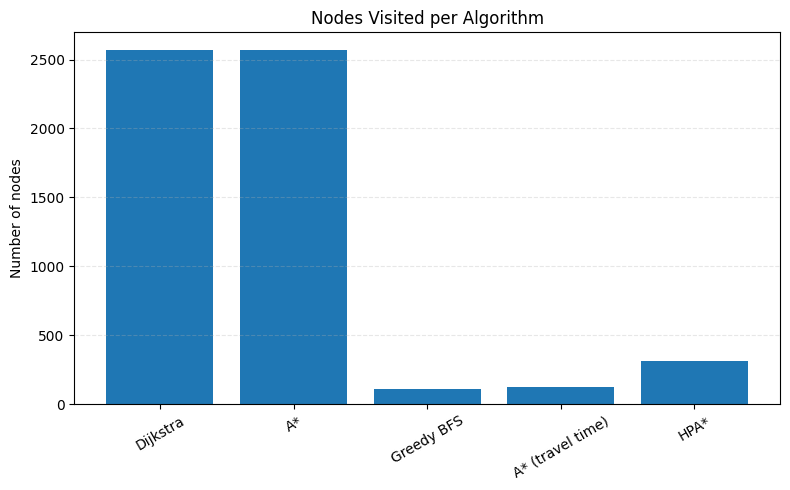

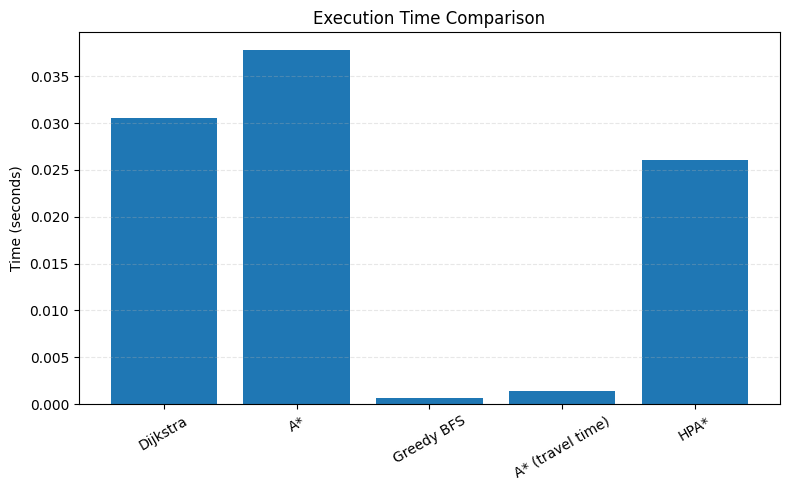

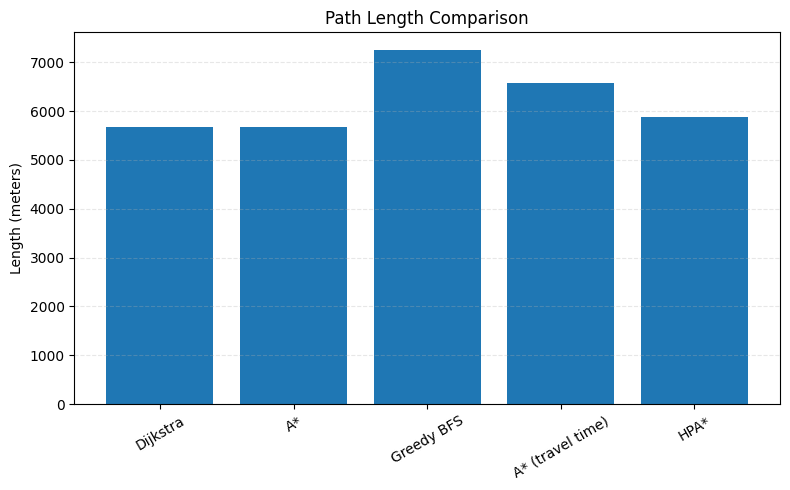

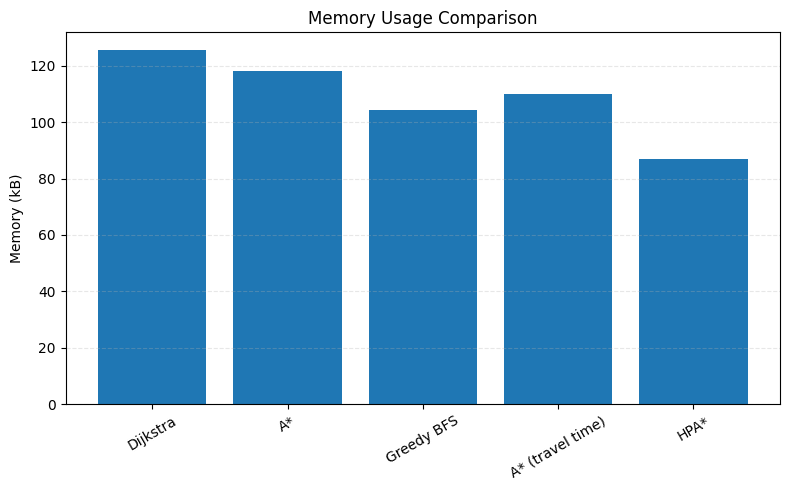

In [53]:
# -------------- PERFORMANCE PLOTS --------------------------------
# Table results
algorithms = df["Algorithm"].tolist()
nodes      = df["Nodes"].tolist()
times      = df["Time (s)"].tolist()
lengths    = df["Length (m)"].tolist()
memory     = df["Memory (kB)"].tolist()
# General Configuration
x = np.arange(len(algorithms))
width = 0.6
plt.rcParams.update({'font.size': 10})

# 1. Visited Nodes
plt.figure(figsize=(8,5))
plt.bar(algorithms, nodes)
plt.title("Nodes Visited per Algorithm")
plt.ylabel("Number of nodes")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 2️. Run Time
plt.figure(figsize=(8,5))
plt.bar(algorithms, times)
plt.title("Execution Time Comparison")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 3️. Path length
plt.figure(figsize=(8,5))
plt.bar(algorithms, lengths)
plt.title("Path Length Comparison")
plt.ylabel("Length (meters)")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 4️. Memory use
plt.figure(figsize=(8,5))
plt.bar(algorithms, memory)
plt.title("Memory Usage Comparison")
plt.ylabel("Memory (kB)")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


SECTION 2:  Logic-Based Pathfinding and Algorithmic Reasoning

1. Constraints Functions

In [55]:
def euclidean_distance(G, u, v):

    y1, x1 = G.nodes[u]['y'], G.nodes[u]['x']
    y2, x2 = G.nodes[v]['y'], G.nodes[v]['x']
    dy = y1 - y2
    dx = x1 - x2
    return math.sqrt(dx*dx + dy*dy)


def node_type(G, n):

    return G.nodes[n].get("type", "normal")


def mark_graph_semantics(G):


    #  Remove any mark
    try:
        # MultiDiGraph (osmnx)
        for u, v, key, data in G.edges(keys=True, data=True):
            data.pop("flood_zone", None)
            data.pop("unsafe", None)
            data.pop("closed", None)
    except TypeError:
        # Graph / DiGraph
        for u, v, data in G.edges(data=True):
            data.pop("flood_zone", None)
            data.pop("unsafe", None)
            data.pop("closed", None)

    # Reset the nodes
    for n in G.nodes:
        G.nodes[n]["type"] = "normal"

    # Choose the real nodes
    hospitales = [213381]   # start node
    comisarias = [213322]   # any another node
    estadios   = []         # leave empty

    for n in hospitales:
        if n in G.nodes:
            G.nodes[n]["type"] = "hospital"

    for n in comisarias:
        if n in G.nodes:
            G.nodes[n]["type"] = "police"

    for n in estadios:
        if n in G.nodes:
            G.nodes[n]["type"] = "stadium"

    # ---------- 3) List of risk edges
    flood_edges  = []   # p.ej. [(u1, v1)]
    unsafe_edges = []   # p.ej. [(u2, v2)]
    closed_edges = []   # p.ej. [(u3, v3)]

    for (u, v) in flood_edges:
        if G.has_edge(u, v):
            for key in G[u][v]:
                G[u][v][key]["flood_zone"] = True

    for (u, v) in unsafe_edges:
        if G.has_edge(u, v):
            for key in G[u][v]:
                G[u][v][key]["unsafe"] = True

    for (u, v) in closed_edges:
        if G.has_edge(u, v):
            for key in G[u][v]:
                G[u][v][key]["closed"] = True

    return G


def is_edge_safe(G, u, v, key=None):

    try:
        # Multi*Graph
        if key is not None:
            edge_data = G[u][v][key]
        else:
            edge_data = next(iter(G[u][v].values()))
    except Exception:
        # Graph/DiGraph
        edge_data = G[u][v]

    if edge_data.get("closed"):
        return False
    if edge_data.get("unsafe"):
        return False
    if edge_data.get("flood_zone"):
        return False

    return True


def passes_through_hospital(G, path):

    return any(node_type(G, n) == "hospital" for n in path)


def passes_through_stadium(G, path):

    return any(node_type(G, n) == "stadium" for n in path)


def contains_safe_hub(G, path):

    return any(node_type(G, n) in ("hospital", "police") for n in path)


def path_satisfies_constraints(G, path):

    if not path:
        return False

    # Constraint 1: Must pass through a safe hub
    if not contains_safe_hub(G, path):
        return False

    # Constraint 2 : Must not pass through to the stadium
    if passes_through_stadium(G, path):
        return False

    # Constraint 3: All the edges have to be safety
    for u, v in zip(path[:-1], path[1:]):
        if not G.has_edge(u, v):
            return False

        # MultiGraph vs Graph
        try:
            key = next(iter(G[u][v].keys()))
        except Exception:
            key = None

        if not is_edge_safe(G, u, v, key=key):
            return False

    return True


def classify_path_pattern(G, path):

    if not path:
        return "no_path"

    has_safe_hub = contains_safe_hub(G, path)
    has_stadium  = passes_through_stadium(G, path)

    risky = False
    for u, v in zip(path[:-1], path[1:]):
        for key, data in G[u][v].items():
            if data.get("flood_zone") or data.get("unsafe") or data.get("closed"):
                risky = True
                break
        if risky:
            break

    pattern = (has_safe_hub, has_stadium, risky)

    match pattern:
        case (True, False, False):
            return "safe_route"
        case (True, True, _):
            return "through_stadium"
        case (False, False, True):
            return "risky_without_hub"
        case (False, False, False):
            return "no_hub_but_safe_edges"
        case _:
            return "mixed_risk"

2. Backtracking Algorithm

In [56]:
def search_with_backtracking(G, start, goal, max_depth=60, max_expanded=5000):

    visited = set()
    path = []
    expanded = 0  # Counted of the expansion nodes

    def dfs(current):
        nonlocal expanded
        expanded += 1


        if expanded > max_expanded:
            return False


        path.append(current)
        visited.add(current)


        if current == goal and path_satisfies_constraints(G, path):
            return True


        if len(path) > max_depth:
            visited.remove(current)
            path.pop()
            return False


        try:
            neighbors = G.successors(current)
        except AttributeError:
            neighbors = G.neighbors(current)

        for neighbor in neighbors:
            if neighbor in visited:
                continue
            if not G.has_edge(current, neighbor):
                continue


            safe = False
            for key in G[current][neighbor]:
                if is_edge_safe(G, current, neighbor, key=key):
                    safe = True
                    break
            if not safe:
                continue


            if dfs(neighbor):
                return True


        visited.remove(current)
        path.pop()
        return False

    ok = dfs(start)
    return list(path) if ok else None


3. Logic A* (Heuristic + A*)

In [57]:
def risk_penalty(G, n):

    node = G.nodes[n]
    penalty = 0


    if node.get("flood_zone"):
        penalty += 500
    if node.get("unsafe_area"):
        penalty += 200
    if node.get("type") == "stadium":
        penalty += 300

    return penalty


def heuristic_logic(G, n, goal):

    base = euclidean_distance(G, n, goal)
    lam = 0.1
    return base + lam * risk_penalty(G, n)


def reconstruct_path(came_from, current):
    path = [current]
    while current in came_from:
        current = came_from[current]
        path.append(current)
    path.reverse()
    return path


def astar_logic(G, start, goal):

    import heapq

    open_set = []
    heapq.heappush(open_set, (0.0, start))

    came_from = {}
    g_score = {start: 0.0}

    visited_count = 0
    closed_set = set()

    while open_set:
        _, current = heapq.heappop(open_set)

        if current in closed_set:
            continue
        closed_set.add(current)
        visited_count += 1

        if current == goal:
            path = reconstruct_path(came_from, current)
            return path, visited_count

        # Neighbor (MultiDiGraph or Graph)
        try:
            neighbors = G.successors(current)
        except AttributeError:
            neighbors = G.neighbors(current)

        for neighbor in neighbors:

            if not G.has_edge(current, neighbor):
                continue

            safe = False
            min_cost_edge = None


            adj = G[current][neighbor]
            if hasattr(adj, "items"):
                iterator = adj.items()  # Multi
            else:
                iterator = [(None, adj)]  # Graph

            for key, data in iterator:
                if is_edge_safe(G, current, neighbor, key):
                    cost = data.get("length", 1.0)
                    if (min_cost_edge is None) or (cost < min_cost_edge):
                        min_cost_edge = cost
                        safe = True

            if not safe:

                continue

            tentative_g = g_score[current] + (min_cost_edge if min_cost_edge is not None else 1.0)

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                g_score[neighbor] = tentative_g
                f_score = tentative_g + heuristic_logic(G, neighbor, goal)
                came_from[neighbor] = current
                heapq.heappush(open_set, (f_score, neighbor))


    return None, visited_count


- Backtracking outcomes

In [58]:
label_astar = classify_path_pattern(G, path_astar_logic)
print(" A*Logic Pattern routez", label_astar)

path_bt = search_with_backtracking(G, start, goal)
label_bt = classify_path_pattern(G, path_bt)
print("Patrón ruta backtracking:", label_bt)

NameError: name 'path_astar_logic' is not defined

4. Set nodes

- Choose some nodes

In [49]:
list(G.nodes)[:10]

[213302,
 213309,
 213313,
 213315,
 213318,
 213319,
 213320,
 213322,
 213323,
 213324]

- Choose the start and goal node.

In [59]:
start = list(G.nodes)[0]
goal  = list(G.nodes)[-1]

print(start, goal)


213302 13258144282


5. Run and compare

In [68]:
G = mark_graph_semantics(G)

start = list(G.nodes)[0]
goal  = list(G.nodes)[-1]

print("Start Node :", start)
print("End Node:", goal)


G.nodes[start]["type"] = "hospital"
G.nodes[goal]["type"]  = "police"


results = []

t0 = time.perf_counter()
path_astar_sec1, visited_astar_sec1 = astar(G, start, goal)
t1 = time.perf_counter()

results.append({
    "algoritmo": "A* original",
    "tiempo_ms": (t1 - t0) * 1000,
    "longitud": len(path_astar_sec1) if path_astar_sec1 else None,
    "visitados": visited_astar_sec1,
    "cumple": path_satisfies_constraints(G, path_astar_sec1) if path_astar_sec1 else None,
})

print("\n Original A* Outcomes (Section 1)")
print("Route (First 10 nodes):",
      path_astar_sec1[:10] if path_astar_sec1 else None)
print("Route Length (nodes):",
      len(path_astar_sec1) if path_astar_sec1 else None)
print("Visited Nodes:", visited_astar_sec1)
print("Satisfy the logic constraints:",
      path_satisfies_constraints(G, path_astar_sec1) if path_astar_sec1 else None)

t0 = time.perf_counter()
path_astar_logic, visited_logic = astar_logic(G, start, goal)
t1 = time.perf_counter()

results.append({
    "algoritmo": "A* lógico",
    "tiempo_ms": (t1 - t0) * 1000,
    "longitud": len(path_astar_logic) if path_astar_logic else None,
    "visitados": visited_logic,
    "cumple": path_satisfies_constraints(G, path_astar_logic) if path_astar_logic else None,
})

print("\n Logic A* Outcomes (Section 2)")
print("Route (First 10 nodes)",
      path_astar_logic[:10] if path_astar_logic else None)
print("Route Length (nodes):",
      len(path_astar_logic) if path_astar_logic else None)
print("Visited Nodes", visited_logic)
print("Satisfy the logic Constraints",
      path_satisfies_constraints(G, path_astar_logic) if path_astar_logic else None)


t0 = time.perf_counter()
path_bt = search_with_backtracking(G, start, goal, max_depth=60)
t1 = time.perf_counter()

results.append({
    "algoritmo": "Backtracking",
    "tiempo_ms": (t1 - t0) * 1000,
    "longitud": len(path_bt) if path_bt else None,
    "visitados": None,  # si no cuentas nodos visitados, déjalo en None
    "cumple": path_satisfies_constraints(G, path_bt) if path_bt else None,
})

print("\n Backtracking Outcomes")
print("Route (First 10 nodes):", path_bt[:10] if path_bt else None)
print("Route Length (nodes):", len(path_bt) if path_bt else None)
print("Satisfy the logic ConstraintsS",
      path_satisfies_constraints(G, path_bt) if path_bt else None)


print("\n Comparison Performance")

header = f"{'Algoritmo':<15} {'Tiempo (ms)':>12} {'Longitud':>10} {'Visitados':>10} {'Cumple?':>10}"
print(header)
print("-" * len(header))

for r in results:
    alg   = r["algoritmo"]
    t_ms  = f"{r['tiempo_ms']:.2f}" if r["tiempo_ms"] is not None else "-"
    long_ = str(r["longitud"]) if r["longitud"] is not None else "-"
    vis   = str(r["visitados"]) if r["visitados"] is not None else "-"
    ok    = str(r["cumple"]) if r["cumple"] is not None else "-"

    print(f"{alg:<15} {t_ms:>12} {long_:>10} {vis:>10} {ok:>10}")


Start Node : 213302
End Node: 13258144282

 Original A* Outcomes (Section 1)
Route (First 10 nodes): [213302, 10069541058, 8399368008, 8399292860, 8399368007, 10069541056, 213313, 213315, 10596563019, 1549114462]
Route Length (nodes): 38
Visited Nodes: 3122
Satisfy the logic constraints: True

 Logic A* Outcomes (Section 2)
Route (First 10 nodes) [213302, 10069541058, 8399368008, 8399292860, 8399368007, 10069541056, 213313, 213315, 10596563019, 1549114462]
Route Length (nodes): 38
Visited Nodes 3116
Satisfy the logic Constraints True

 Backtracking Outcomes
Route (First 10 nodes): None
Route Length (nodes): None
Satisfy the logic ConstraintsS None

 Comparison Performance
Algoritmo        Tiempo (ms)   Longitud  Visitados    Cumple?
-------------------------------------------------------------
A* original            26.10         38       3122       True
A* lógico              40.87         38       3116       True
Backtracking           56.98          -          -          -


- Backtracking results

In [69]:
label_astar = classify_path_pattern(G, path_astar_logic)
print("Patrón ruta A* lógica:", label_astar)

path_bt = search_with_backtracking(G, start, goal, max_depth=60)
print("Ruta backtracking (primeros 10 nodos):", path_bt[:10] if path_bt else None)

label_bt = classify_path_pattern(G, path_bt)
print("Patrón ruta backtracking:", label_bt)


Patrón ruta A* lógica: safe_route
Ruta backtracking (primeros 10 nodos): None
Patrón ruta backtracking: no_path


Checking Constraints on final path

In [71]:
path = path_astar_logic

if path is None:
    print("❌ We don´t find the  A* lógico (path_astar_logic = None).")
    print("   - Try again to run the cell where you call to astar_logic(G, start, goal)")
    print("   - Or check the constraints")
else:
    print("=== CHECKING CONSTRAINTS ON FINAL PATH ===")
    print("Ruta:", path[:10], "... (longitud:", len(path), ")")

    print("Pass through to hospital?:", passes_through_hospital(G, path))
    print("Pass through to the stadium?:", passes_through_stadium(G, path))
    print("Have a safe hub (hospital/police)?:", contains_safe_hub(G, path))

    print("\n Any edge unsafety?:")
    unsafe_edges = []
    for u, v in zip(path[:-1], path[1:]):
        for key, data in G[u][v].items():
            if not is_edge_safe(G, u, v, key=key):
                unsafe_edges.append((u, v))
    print(unsafe_edges)

    print("\n Satisfy all the constraints?:", path_satisfies_constraints(G, path))



=== CHECKING CONSTRAINTS ON FINAL PATH ===
Ruta: [213302, 10069541058, 8399368008, 8399292860, 8399368007, 10069541056, 213313, 213315, 10596563019, 1549114462] ... (longitud: 38 )
Pass through to hospital?: True
Pass through to the stadium?: False
Have a safe hub (hospital/police)?: True

 Any edge unsafety?:
[]

 Satisfy all the constraints?: True


- Show the map with the constraints added

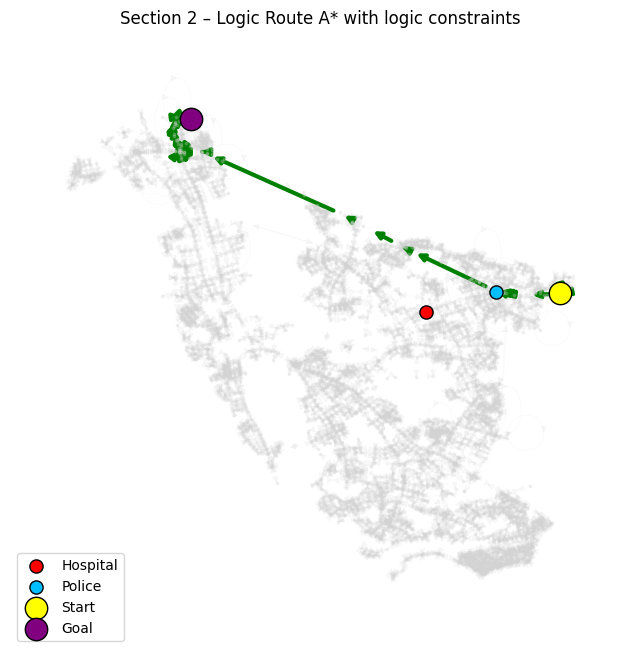

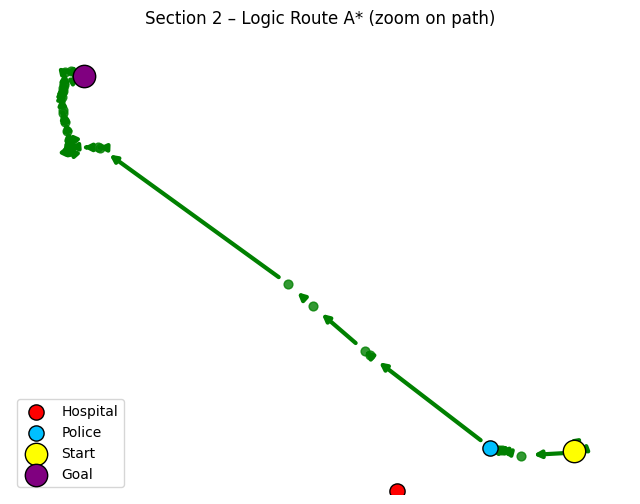

In [74]:
path = path_astar_logic

if path is None:
    print(" We can show the map because the path_astar_logic = None.")
else:

    pos = {n: (G.nodes[n]["x"], G.nodes[n]["y"]) for n in G.nodes}

    hospitals = [n for n, d in G.nodes(data=True) if d.get("type") == "hospital"]
    police    = [n for n, d in G.nodes(data=True) if d.get("type") == "police"]
    stadiums  = [n for n, d in G.nodes(data=True) if d.get("type") == "stadium"]
    others    = [n for n, d in G.nodes(data=True) if d.get("type", "normal") == "normal"]

    safe_edges   = []
    unsafe_edges = []
    closed_edges = []
    flood_edges  = []

    for u, v, key, data in G.edges(keys=True, data=True):
        if data.get("closed"):
            closed_edges.append((u, v))
        elif data.get("unsafe"):
            unsafe_edges.append((u, v))
        elif data.get("flood_zone"):
            flood_edges.append((u, v))
        else:
            safe_edges.append((u, v))

    path_edges = list(zip(path[:-1], path[1:]))


    plt.figure(figsize=(8, 8))

    nx.draw_networkx_edges(G, pos, edgelist=safe_edges,
                           width=0.4, alpha=0.15, edge_color="lightgrey")

    nx.draw_networkx_edges(G, pos, edgelist=flood_edges,
                           width=1.5, alpha=0.9, edge_color="blue",  style="dashed", label="Flood zone")
    nx.draw_networkx_edges(G, pos, edgelist=unsafe_edges,
                           width=1.5, alpha=0.9, edge_color="orange", style="dashed", label="Unsafe")
    nx.draw_networkx_edges(G, pos, edgelist=closed_edges,
                           width=1.5, alpha=0.9, edge_color="red",   style="dashed", label="Closed")


    nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                           width=3, edge_color="green", label="Logic A* route")


    nx.draw_networkx_nodes(G, pos, nodelist=others,
                           node_size=3, node_color="lightgrey", alpha=0.25)
    nx.draw_networkx_nodes(G, pos, nodelist=hospitals,
                           node_size=90, node_color="red", edgecolors="black", label="Hospital")
    nx.draw_networkx_nodes(G, pos, nodelist=police,
                           node_size=90, node_color="deepskyblue", edgecolors="black", label="Police")
    nx.draw_networkx_nodes(G, pos, nodelist=stadiums,
                           node_size=80, node_color="magenta", edgecolors="black", label="Stadium")

    plt.scatter(G.nodes[start]["x"], G.nodes[start]["y"],
                s=260, c="yellow", edgecolors="black", zorder=6, label="Start")
    plt.scatter(G.nodes[goal]["x"], G.nodes[goal]["y"],
                s=260, c="purple", edgecolors="black", zorder=6, label="Goal")

    plt.title("Section 2 – Logic Route A* with logic constraints")
    plt.axis("off")
    plt.legend(loc="lower left")
    plt.show()


    xs = [G.nodes[n]["x"] for n in path]
    ys = [G.nodes[n]["y"] for n in path]

    margin_x = (max(xs) - min(xs)) * 0.1 if max(xs) != min(xs) else 0.001
    margin_y = (max(ys) - min(ys)) * 0.1 if max(ys) != min(ys) else 0.001

    plt.figure(figsize=(8, 6))

    nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                           width=3, edge_color="green", label="Logic A* route")
    nx.draw_networkx_nodes(G, pos, nodelist=path,
                           node_size=40, node_color="green", alpha=0.8)

    nx.draw_networkx_nodes(G, pos, nodelist=hospitals,
                           node_size=120, node_color="red", edgecolors="black", label="Hospital")
    nx.draw_networkx_nodes(G, pos, nodelist=police,
                           node_size=120, node_color="deepskyblue", edgecolors="black", label="Police")

    plt.scatter(G.nodes[start]["x"], G.nodes[start]["y"],
                s=260, c="yellow", edgecolors="black", zorder=6, label="Start")
    plt.scatter(G.nodes[goal]["x"], G.nodes[goal]["y"],
                s=260, c="purple", edgecolors="black", zorder=6, label="Goal")

    plt.xlim(min(xs) - margin_x, max(xs) + margin_x)
    plt.ylim(min(ys) - margin_y, max(ys) + margin_y)

    plt.title("Section 2 – Logic Route A* (zoom on path)")
    plt.axis("off")
    plt.legend(loc="lower left")
    plt.show()
